#### Convolución

Para qué se usa una convolución
Reducción de la dimensión del arreglo -> menos pesos
Tamaño del kernel es parámetro libre (podemos ir probando)


#### Padding

Preserva dimensiones


#### Stride

Va por bloques completos



"Secuencual" = capas completamente conectadas

cada neurona tiene su bias

Clasificación tiene en la última capa tantas neuronas como labels. Regresión tiene una sola neurona que regresa un número que tienes que interpretar.

### Activar ambiente "folps_env"

In [1]:
import numpy as np
from PIL import Image
import random
import os
import tensorflow as tf

In [2]:
cats = []
dogs = []

for archivo in os.listdir('PetImages/Cat'):
    try:
        img = Image.open('PetImages/Cat/' + archivo).convert('RGB')
        cats.append(img.resize((64,64)))
    except:
        pass

for archivo in os.listdir('PetImages/Dog'):
    try:
        img = Image.open('PetImages/Dog/' + archivo).convert('RGB')
        dogs.append(img.resize((64,64)))
    except:
        pass

/Users/jcimental/venvs/folps_env/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [3]:
len(cats), len(dogs)

(12490, 12469)

In [4]:
len(cats) + len(dogs)

24959

In [5]:
datos = [(x,1) for x in cats] + [(x,0) for x in dogs]     ## labels para gatos y perros

random.shuffle(datos)  

In [6]:
X = [x for x,y in datos]
Y = [y for x,y in datos]

X = np.array(X)
Y = np.array(Y)

In [7]:
X.shape

(24959, 64, 64, 3)

In [8]:
X_flat = X.reshape(len(Y), -1)/255.0 

In [9]:
X_flat.shape

(24959, 12288)

In [10]:
corte = int(0.8*len(Y))   ## Separamos el 80% de los datos

X_train = X_flat[:corte]   ### FLAT
Y_train = Y[:corte]

X_test = X_flat[corte:]
Y_test = Y[corte:]

In [11]:
x_train = X[:corte]   ### NON-FLAT
y_train = Y[:corte]

x_test = X[corte:]
y_test = Y[corte:]

In [12]:
X_train.shape, X_test.shape, x_train.shape, x_test.shape

((19967, 12288), (4992, 12288), (19967, 64, 64, 3), (4992, 64, 64, 3))

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1,                     ## Una capa de salida: {0,1}
                          activation='sigmoid',
                          input_shape=(X_flat.shape[1],))])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │        12,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), # función costo para clasificación binaria
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)

In [18]:
history = model.fit(
    X_train,Y_train,
    epochs=50,
    validation_data=(X_test,Y_test)
)

Epoch 1/50


/Users/jcimental/venvs/folps_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:1288: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5162 - loss: 2.6603 - val_accuracy: 0.5577 - val_loss: 1.2375
Epoch 2/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.5230 - loss: 2.4711 - val_accuracy: 0.5962 - val_loss: 0.8958
Epoch 3/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - accuracy: 0.5362 - loss: 2.4009 - val_accuracy: 0.4932 - val_loss: 4.9647
Epoch 4/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - accuracy: 0.5336 - loss: 2.4337 - val_accuracy: 0.5228 - val_loss: 2.4681
Epoch 5/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.5392 - loss: 2.3400 - val_accuracy: 0.5968 - val_loss: 0.9602
Epoch 6/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.5385 - loss: 2.3272 - val_accuracy: 0.5306 - val_loss: 1.8752
Epoch 7/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.5433 - loss: 2.3011 - val_accuracy: 0.5242 - val_loss: 2.6103
Epoch 8/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - accuracy: 0.5400 - loss: 2.3510 - val_accuracy:

Text(0.5, 1.0, 'LOSS')

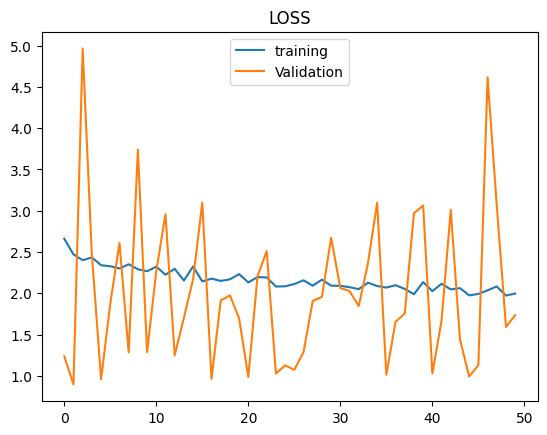

In [19]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [20]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=10, activation='relu6',input_shape=(X_flat.shape[1],)),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
model_2.summary()

model_2.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(model_2)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │       122,890 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,901 (480.08 KB)

 Trainable params: 122,901 (480.08 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [21]:
history_2 = model_2.fit(
    X_train,Y_train,
    epochs=30,
    validation_data=(X_test,Y_test)
)

Epoch 1/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5519 - loss: 0.6863 - val_accuracy: 0.5841 - val_loss: 0.6780
Epoch 2/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5957 - loss: 0.6698 - val_accuracy: 0.5998 - val_loss: 0.6648
Epoch 3/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6103 - loss: 0.6597 - val_accuracy: 0.6000 - val_loss: 0.6613
Epoch 4/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6171 - loss: 0.6537 - val_accuracy: 0.5986 - val_loss: 0.6633
Epoch 5/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6181 - loss: 0.6506 - val_accuracy: 0.6018 - val_loss: 0.6608
Epoch 6/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6229 - loss: 0.6472 - val_accuracy: 0.6162 - val_loss: 0.6516
Epoch 7/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6279 - loss: 0.6444 - val_accuracy: 0.6148 - val_loss: 0.6540
Epoch 8/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6323 - loss: 0.6418 - val_accuracy: 0.

Text(0.5, 1.0, 'LOSS')

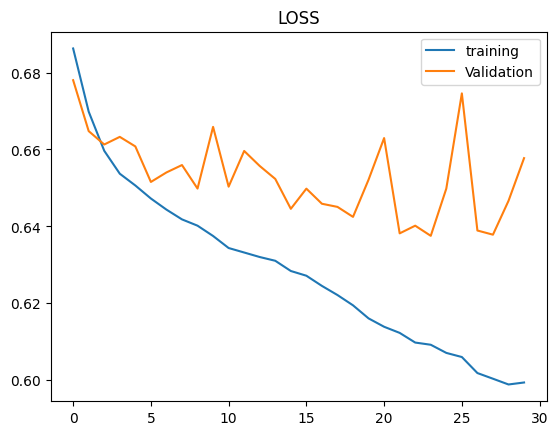

In [22]:
train_loss = history_2.history['loss']
val_loss = history_2.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [23]:
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=512, activation='relu',input_shape=(X_flat.shape[1],)),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
model_5.summary()
model_5.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(model_5)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,555,137 (25.01 MB)

 Trainable params: 6,555,137 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [24]:
history_5 = model_5.fit(
    X_train,Y_train,
    epochs=30,
    validation_data=(X_test,Y_test)
)

Epoch 1/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5786 - loss: 0.6732 - val_accuracy: 0.5942 - val_loss: 0.6652
Epoch 2/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6231 - loss: 0.6465 - val_accuracy: 0.5563 - val_loss: 0.6948
Epoch 3/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6361 - loss: 0.6357 - val_accuracy: 0.6342 - val_loss: 0.6323
Epoch 4/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6426 - loss: 0.6271 - val_accuracy: 0.6092 - val_loss: 0.6481
Epoch 5/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6523 - loss: 0.6190 - val_accuracy: 0.6404 - val_loss: 0.6321
Epoch 6/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6585 - loss: 0.6108 - val_accuracy: 0.6404 - val_loss: 0.6230
Epoch 7/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6709 - loss: 0.6027 - val_accuracy: 0.6474 - val_loss: 0.6220
Epoch 8/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6761 - loss: 0.5979 - v

Text(0.5, 1.0, 'LOSS')

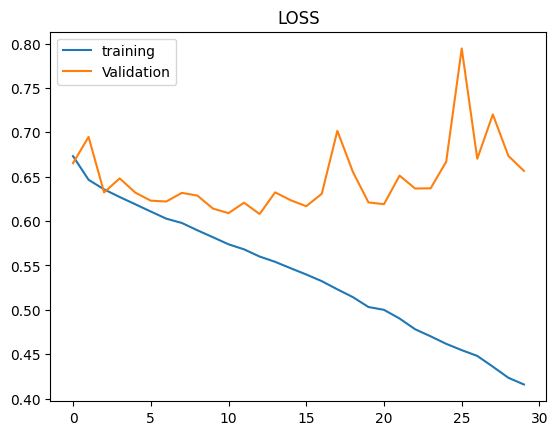

In [25]:
train_loss = history_5.history['loss']
val_loss = history_5.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [29]:
modelConv_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),strides=(2,2),padding='valid',input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
modelConv_1.summary()
modelConv_1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), #loss function for multiple categories
    optimizer='adam',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(modelConv_1)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15376)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     7,873,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873,985 (30.04 MB)

 Trainable params: 7,873,985 (30.04 MB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [30]:
history_conv1 = modelConv_1 .fit(
    x_train,y_train,
    batch_size =128,
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.5450 - loss: 66.3287 - val_accuracy: 0.5765 - val_loss: 0.9446
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.5905 - loss: 0.7870 - val_accuracy: 0.5531 - val_loss: 1.0194
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.5927 - loss: 0.8874 - val_accuracy: 0.5294 - val_loss: 0.9194
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.6103 - loss: 0.7280 - val_accuracy: 0.5903 - val_loss: 0.7252
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.6271 - loss: 0.6770 - val_accuracy: 0.6012 - val_loss: 0.7565
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.6207 - loss: 0.6951 - val_accuracy: 0.5124 - val_loss: 0.7036
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.5331 - loss: 0.6834 - val_accuracy: 0.5887 - val_loss: 0.6791
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.6113 - loss: 0.6669 

(-0.1, 1.1)

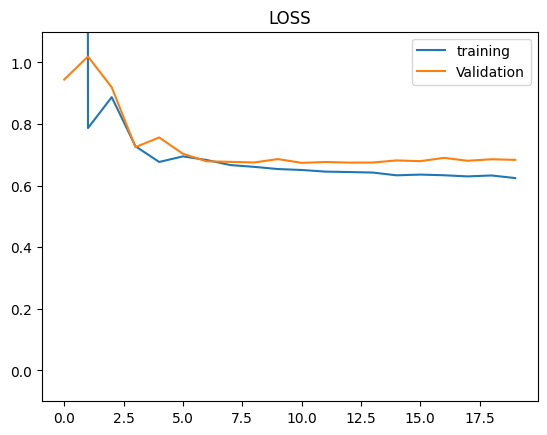

In [37]:
train_loss = history_conv1.history['loss']
val_loss = history_conv1.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")
plt.ylim(-0.1, 1.1)

In [32]:
modelConv_2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),strides=(2,2),padding='valid',input_shape=(64,64,3)),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),strides=(2,2),padding='valid',activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
modelConv_2.summary()
modelConv_2.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), #loss function for multiple categories
    optimizer='adam',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(modelConv_2)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 31, 31, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       803,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 808,929 (3.09 MB)

 Trainable params: 808,929 (3.09 MB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [33]:
history_conv2 = modelConv_2 .fit(
    x_train,y_train,
    batch_size =128,
    epochs=10,
    validation_data=(x_test,y_test)
)

Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5389 - loss: 4.0276 - val_accuracy: 0.5423 - val_loss: 0.7041
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5980 - loss: 0.6496 - val_accuracy: 0.5681 - val_loss: 0.7068
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6476 - loss: 0.5956 - val_accuracy: 0.5837 - val_loss: 0.7154
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6991 - loss: 0.5299 - val_accuracy: 0.5889 - val_loss: 0.7398
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7445 - loss: 0.4627 - val_accuracy: 0.5865 - val_loss: 0.7888
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7877 - loss: 0.3994 - val_accuracy: 0.5968 - val_loss: 0.8426
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8232 - loss: 0.3440 - val_accuracy: 0.6132 - val_loss: 0.9282
Epoch 8/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8472 - loss: 0.3035 - val_accu

Text(0.5, 1.0, 'LOSS')

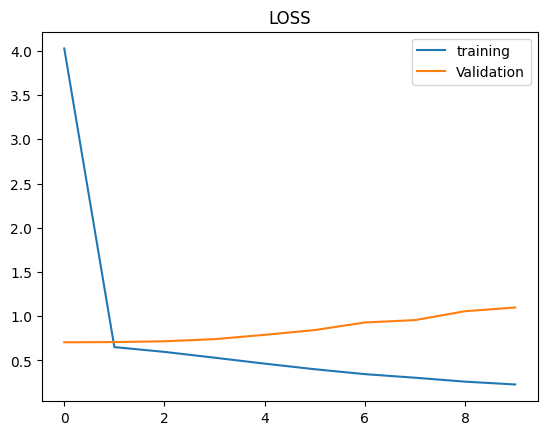

In [34]:
train_loss = history_conv2.history['loss']
val_loss = history_conv2.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")